In [ ]:
# ============================================================
# 環境設定（Colab/ローカル共通）
# ============================================================
import os

# Google Earth Engineプロジェクト ID（ご自身のGEEプロジェクトIDに変更）
GEE_PROJECT = os.environ.get('GEE_PROJECT', 'your-ee-project-id')

# 出力ディレクトリ（Colabの場合は/content/drive/MyDrive/...、ローカルの場合は任意のパス）
OUTPUT_DIR = os.environ.get('OUTPUT_DIR', '/content/drive/MyDrive/Downscaling')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'GEE_PROJECT: {GEE_PROJECT}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')


In [1]:
import pandas as pd
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
from google.colab import files


In [2]:

def compute_correction_factors(df_obs, df_gcm):

    df_gcm.index = pd.to_datetime(df_gcm.index)
    df_obs = df_obs.rename(columns={"GSMaP": "obs"})
    obs_values = df_obs["obs"].values
    df_obs = pd.DataFrame(obs_values, index=df_gcm.index, columns=["obs"])

    df_raw = df_obs.join(df_gcm)
    gcm_cols = df_gcm.columns

    df_corr1 = pd.DataFrame(index=range(len(df_raw)), columns=gcm_cols)
    obs_sorted_vals = df_raw.iloc[:, 0].sort_values().values
    for col in gcm_cols:
        gcm_vals = df_raw[col].sort_values().values
        df_corr1[col] = [obs / gcm if gcm > 0 else 0 for obs, gcm in zip(obs_sorted_vals, gcm_vals)]

    df_corr2 = {month: pd.DataFrame(columns=gcm_cols) for month in range(1, 13)}
    for month in range(1, 13):
        df_month = df_raw[df_raw.index.month == month]
        obs_sorted_vals = df_month.iloc[:, 0].sort_values()
        for col in gcm_cols:
            gcm_sorted_vals = df_month[col].sort_values()
            coeffs = [
                obs / gcm if gcm > 0 else 0
                for obs, gcm in zip(obs_sorted_vals.values, gcm_sorted_vals.values)
            ]
            df_corr2[month][col] = pd.Series(coeffs, index=gcm_sorted_vals.index)

    zero_count = (df_raw.iloc[:, 0] == 0).sum()
    df_adj_temp = df_raw.copy()
    for month in range(1, 13):
        df_month = df_raw[df_raw.index.month == month]
        for col in gcm_cols:
            sorted_idx = df_month[col].sort_values().index
            coeff_series = df_corr2[month][col]
            valid_len = min(len(sorted_idx), len(coeff_series))
            if valid_len == 0:
                continue
            values = df_month.loc[sorted_idx[:valid_len], col].values
            coeffs = coeff_series.iloc[:valid_len].values
            df_adj_temp.loc[sorted_idx[:valid_len], col] = values * coeffs

    zero_thresholds = {}
    for col in gcm_cols:
        sorted_vals = df_adj_temp[col].sort_values().values
        if zero_count > 0 and zero_count <= len(sorted_vals):
            threshold = sorted_vals[zero_count - 1]
        else:
            threshold = 0
        zero_thresholds[col] = threshold

    return df_corr1, df_corr2, zero_thresholds

In [4]:
def apply_correction(df_target, df_corr1, df_corr2, zero_thresholds):
    df_target.index = pd.to_datetime(df_target.index)
    df_adj1 = df_target.copy()
    gcm_cols = df_target.columns

    for col in gcm_cols:
        sorted_idx = df_target[col].sort_values().index.to_numpy()
        N = min(len(sorted_idx), len(df_corr1))
        coeffs = df_corr1[col].values[:N]
        dates = sorted_idx[:N]
        df_adj1.loc[dates, col] = df_target.loc[dates, col].values * coeffs

    df_adj2_1 = df_target.copy()
    for month in range(1, 13):
        df_month = df_target[df_target.index.month == month]
        for col in gcm_cols:
            coeff_series = df_corr2[month][col]
            if len(coeff_series) == 0 or df_month[col].sum() == 0:
                continue
            sorted_idx = df_month[col].sort_values().index
            valid_len = min(len(sorted_idx), len(coeff_series))
            values = df_month.loc[sorted_idx[:valid_len], col].values
            coeffs = coeff_series.iloc[:valid_len].values
            df_adj2_1.loc[sorted_idx[:valid_len], col] = values * coeffs

    df_adj2_2 = df_adj2_1.copy()
    for col in gcm_cols:
        threshold = zero_thresholds.get(col, 0)
        df_adj2_2[col] = df_adj2_2[col].apply(lambda x: 0 if x <= threshold else x)

    df_final = df_target.copy()
    for col in gcm_cols:
        sorted_idx = df_target[col].sort_values().index
        threshold = int(np.floor(0.9 * len(sorted_idx)))
        top_idx = sorted_idx[threshold:]
        bot_idx = sorted_idx[:threshold]
        df_final.loc[top_idx, col] = df_adj1.loc[top_idx, col]
        df_final.loc[bot_idx, col] = df_adj2_2.loc[bot_idx, col]


    return df_final

In [5]:
import re
from pathlib import Path

ssp_list = ["ssp126", "ssp585"]

def build_id_path_map(root_dir: str, filename_regex: str) -> dict[int, str]:
    rx = re.compile(filename_regex)
    mapping: dict[int, str] = {}

    for p in Path(root_dir).rglob("*.csv"):
        m = rx.search(p.name)
        if m:
            mapping[int(m.group(1))] = str(p)
    return mapping

def find_file_by_name(root_dir: str, filename: str) -> str | None:
    hits = list(Path(root_dir).rglob(filename))
    return str(hits[0]) if hits else None
obs_map = build_id_path_map("/content", r"his_GSMaP_id_(\d+)\.csv$")
his_map = build_id_path_map("/content", r"his_id_(\d+)\.csv$")

id_list = sorted(set(obs_map.keys()) & set(his_map.keys()))
print("Detected IDs:", id_list)

for id in id_list:
    obs_path = obs_map[id]
    his_path = his_map[id]

    df_obs = pd.read_csv(obs_path).fillna(0)
    df_obs["date"] = pd.to_datetime(df_obs["date"])
    df_obs = df_obs.set_index("date")[["GSMaP"]].rename(columns={"GSMaP": "obs"})

    df_his = pd.read_csv(his_path, index_col=0, parse_dates=True)

    df_corr1, df_corr2, zero_thresholds = compute_correction_factors(df_obs, df_his)
    his_corrected = apply_correction(df_his, df_corr1, df_corr2, zero_thresholds)

    os.makedirs("/content/his_corr", exist_ok=True)
    his_corrected.to_csv(f"/content/his_corr/his_id_{id}_corrected.csv")

    for ssp in ssp_list:
        fut_name = f"fut_{ssp}_id_{id}.csv"
        fut_path = f"/content/{fut_name}"
        if not os.path.exists(fut_path):
            alt = find_file_by_name("/content", fut_name)
            if alt is None:
                print(f"⚠️ No file : {fut_name}")
                continue
            fut_path = alt

        out_dir = f"/content/{ssp}_corr"
        out_path = f"{out_dir}/fut_{ssp}_id_{id}_corrected.csv"

        df_fut = pd.read_csv(fut_path, index_col=0, parse_dates=True).fillna(0)
        fut_corrected = apply_correction(df_fut, df_corr1, df_corr2, zero_thresholds)

        os.makedirs(out_dir, exist_ok=True)
        fut_corrected.to_csv(out_path)

Detected IDs: [0]


In [9]:
def get_top10_sorted(df, col):
    valid_series = df[col].dropna()
    sorted_vals = valid_series.sort_values(ascending=False).reset_index(drop=True)
    top10 = sorted_vals.iloc[:int(0.10 * len(sorted_vals))]
    return top10.reset_index(drop=True)

In [10]:
# Compiling and downloading
for folder in ["his_corr"] + [f"{ssp}_corr" for ssp in ssp_list]:
    zip_path = f"/content/{folder}.zip"
    shutil.make_archive(f"/content/{folder}", 'zip', f"/content/{folder}")
    files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

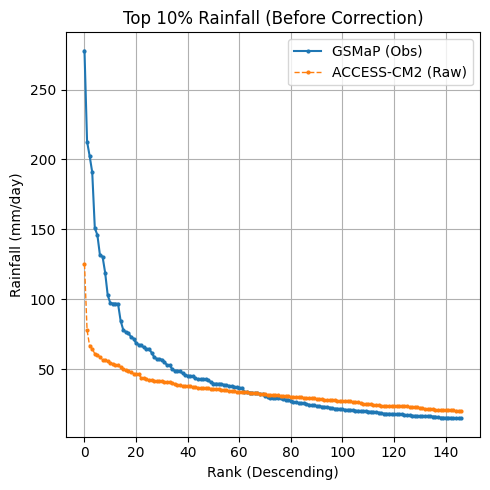

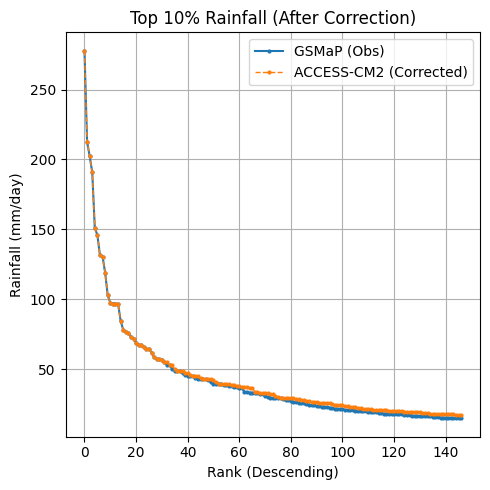

In [11]:
def find_best(root_dir: str, filename: str) -> str:
    hits = list(Path(root_dir).rglob(filename))
    if not hits:
        raise FileNotFoundError(f"Not found under {root_dir}: {filename}")
    hits.sort(key=lambda p: p.stat().st_size, reverse=True)
    return str(hits[0])

def get_top10_sorted(df, col):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s = s.sort_values(ascending=False).reset_index(drop=True)
    if len(s) == 0:
        return s
    k = max(2, int(np.ceil(0.10 * len(s))))
    k = min(len(s), k)
    return s.iloc[:k].reset_index(drop=True)

plot_id = 0

raw_path  = find_best("/content", f"his_id_{plot_id}.csv")
corr_path = find_best("/content", f"his_id_{plot_id}_corrected.csv")
obs_path  = find_best("/content", f"his_GSMaP_id_{plot_id}.csv")

df_raw  = pd.read_csv(raw_path,  index_col=0, parse_dates=True).fillna(0)
df_corr = pd.read_csv(corr_path, index_col=0, parse_dates=True).fillna(0)

df_obs = pd.read_csv(obs_path).fillna(0)
df_obs["date"] = pd.to_datetime(df_obs["date"], errors="coerce")
df_obs = df_obs.dropna(subset=["date"]).set_index("date")[["GSMaP"]].rename(columns={"GSMaP": "obs"}).fillna(0)

plt.figure(figsize=(5,5))
plt.title("Top 10% Rainfall (Before Correction)")
plt.xlabel("Rank (Descending)")
plt.ylabel("Rainfall (mm/day)")
plt.grid(True)
plt.plot(get_top10_sorted(df_obs, "obs").values, marker="o", markersize=2, linewidth=1.5, label="GSMaP (Obs)")
for col in df_raw.columns:
    plt.plot(get_top10_sorted(df_raw, col).values, marker="o", markersize=2, linestyle="--", linewidth=1.0, label=f"{col} (Raw)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.title("Top 10% Rainfall (After Correction)")
plt.xlabel("Rank (Descending)")
plt.ylabel("Rainfall (mm/day)")
plt.grid(True)
plt.plot(get_top10_sorted(df_obs, "obs").values, marker="o", markersize=2, linewidth=1.5, label="GSMaP (Obs)")
for col in df_corr.columns:
    plt.plot(get_top10_sorted(df_corr, col).values, marker="o", markersize=2, linestyle="--", linewidth=1.0, label=f"{col} (Corrected)")
plt.legend()
plt.tight_layout()
plt.show()
